In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import os

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error as rmse

In [2]:
by_day_data = '../data/schedule_data/processed_data/by_day_with_count'
by_day_data = by_day_data
dataframes = [pd.read_csv(os.path.join(by_day_data,x)) for x in os.listdir(by_day_data) if x[-4:] == '.csv']
daily_df = pd.concat(dataframes, ignore_index=True)
daily_df['date'] = daily_df['date'].apply(lambda x: pd.Timestamp(x))
daily_df = daily_df[daily_df['date'].between(pd.Timestamp('2024-07-30'), pd.Timestamp('2025-09-01'), inclusive='left')]

daily_df = daily_df.rename(columns={'delay time (5,19]':'dt_short', 'delay time (19,120]':'dt_long', 'EB/WB':'dir'})

In [3]:
daily_df.head()

,date,dir,stop,bunch,gap,dt_short,dt_long,No. of Veh,Run time (min),Term time (min),Avg. spd (km/h),RT dist (km),Interruption
0,2024-07-30,E,Indian Rd,0,0,0,0,16.4,153.4,10.6,11.92,30.13,0
1,2024-07-30,E,Blackburn St,0,0,0,0,16.4,153.4,10.6,11.92,30.13,0
2,2024-07-30,E,Ossington Ave,0,0,0,0,16.4,153.4,10.6,11.92,30.13,0
3,2024-07-30,W,Gerrard St East at Beaton Ave,12,10,10,0,16.4,153.4,10.6,11.92,30.13,0
4,2024-07-30,E,Howard Park Ave at Indian Rd,0,0,0,0,16.4,153.4,10.6,11.92,30.13,0


In [4]:
daily_df[daily_df.stop == 'Main St'].stop.unique()

array(['Main St'], dtype=object)

In [5]:
daily_df.date = daily_df.date.apply(pd.Timestamp)

In [6]:
# I want to add daily weather data. 
weather=pd.read_csv('../data/raw_data/Weatherstats_data/weatherstats_toronto_daily.csv')
#drop columns that consist exclusively of NaNs
weather.dropna(axis=1, how='all', inplace=True)
#Convert date from string to datetime type
weather.date = weather.date.apply(pd.Timestamp)

#fill remainder of the NaNs with '0'
weather.fillna(0, inplace=True)

columns = weather.columns
#the following columns have a deterministic relationship with the temperature so we are dropping them
columns = [x for x in columns if 'degdays' not in x]

# Choosing avg stats vs max/min stats
columns = [x for x in columns if 'max' not in x and 'min' not in x]
# Removing 'hourly data'
columns = [x for x in columns if 'hourly' not in x]
# Picking one time format
columns = [x for x in columns if 'sunrise_f' != x and 'sunset_f' != x]
columns = [x for x in columns if 'unixtime' not in x]
# Picking station pressure vs sea pressure
columns = [x for x in columns if 'avg_pressure_sea' != x]


weather['sunrise_hhmm'] = weather['sunrise_hhmm'].apply(pd.Timedelta)
weather['sunset_hhmm'] = weather['sunset_hhmm'].apply(pd.Timedelta)

weather = weather[columns]

In [7]:
first_date = daily_df['date'].min()
last_date = daily_df['date'].max()
weather = weather[weather['date'].between(first_date,last_date)]
weather.head()

,date,avg_temperature,avg_relative_humidity,avg_dew_point,avg_wind_speed,wind_gust_dir_10s,avg_pressure_station,avg_visibility,avg_health_index,precipitation,rain,snow,snow_on_ground,sunrise_hhmm,sunset_hhmm,daylight,avg_cloud_cover_8
197,2025-08-31,16.39,57.5,9.1,8.5,0.0,100.36,24100,2.0,0.0,0.0,0.0,0.0,0 days 06:40:00,0 days 19:55:00,13.25,2.0
198,2025-08-30,15.00,58.5,7.5,13.0,31.0,99.96,24100,2.0,0.0,0.0,0.0,0.0,0 days 06:39:00,0 days 19:57:00,13.30,3.5
199,2025-08-29,13.55,64.5,6.0,19.5,31.0,99.73,24100,1.7,0.0,0.0,0.0,0.0,0 days 06:38:00,0 days 19:59:00,13.35,4.0
200,2025-08-28,14.95,73.5,11.8,17.5,32.0,99.53,18500,2.2,5.4,5.4,0.0,0.0,0 days 06:36:00,0 days 20:00:00,13.40,4.0
201,2025-08-27,17.00,58.0,6.7,19.5,26.0,99.86,24100,2.1,0.0,0.0,0.0,0.0,0 days 06:35:00,0 days 20:02:00,13.45,3.0


In [8]:
daily_df = pd.merge(daily_df, weather, on='date')

In [9]:
daily_df.head()

,date,dir,stop,bunch,gap,dt_short,dt_long,No. of Veh,Run time (min),Term time (min),...,avg_visibility,avg_health_index,precipitation,rain,snow,snow_on_ground,sunrise_hhmm,sunset_hhmm,daylight,avg_cloud_cover_8
0,2024-07-30,E,Indian Rd,0,0,0,0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0
1,2024-07-30,E,Blackburn St,0,0,0,0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0
2,2024-07-30,E,Ossington Ave,0,0,0,0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0
3,2024-07-30,W,Gerrard St East at Beaton Ave,12,10,10,0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0
4,2024-07-30,E,Howard Park Ave at Indian Rd,0,0,0,0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0


In [10]:
# Fill na values with 0
daily_df.fillna(0, inplace=True)

In [11]:
features = ['dir', 'bunch', 'gap', 'Interruption']+weather.columns.to_list()
targets = [x for x in daily_df.columns if 'dt_' in x]

In [12]:
corr_matrix = daily_df[features+targets].select_dtypes(np.number).corr()

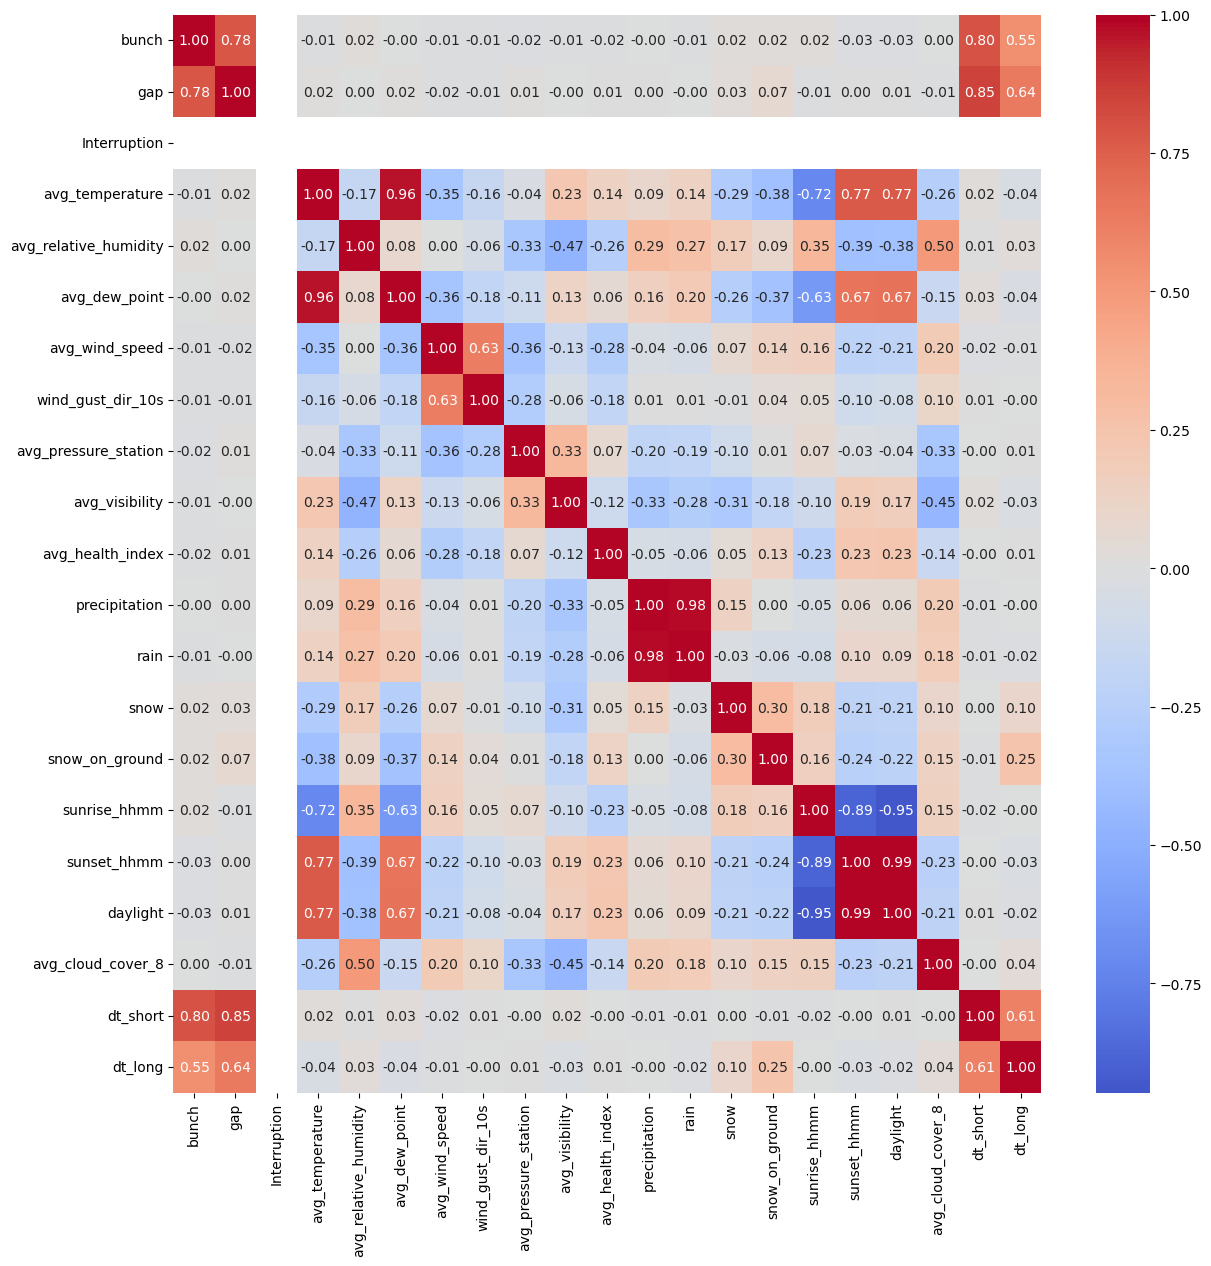

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,14))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f')
plt.show()

Most of these columns are either essentially repeats of other columns, or totally uncorrelated, except for the following features:
- Bunch, Gap, Interruption, avg_temperature, avg_wind_speed, avg_visibility, avg_health_index, rain, snow_on_ground, daylight

Interestingly, factors like windspeed seem to not play any role on the data.

Lets build a model around these features. First let's see a truncated version of the correlation matrix with only these features.

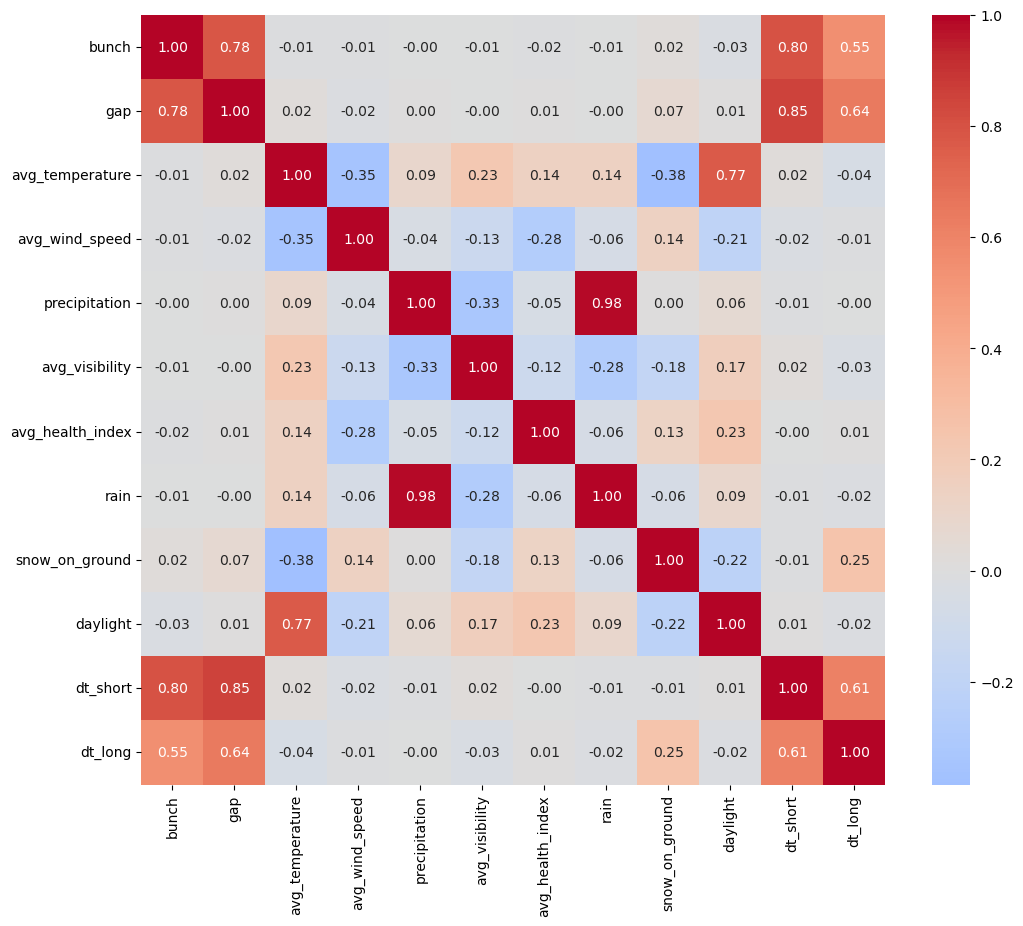

In [14]:
features = ['bunch', 'gap','avg_temperature', 'avg_wind_speed', 'precipitation', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight']
targets = [x for x in daily_df.columns if 'dt_' in x]

corr_matrix = daily_df[features+targets].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f');

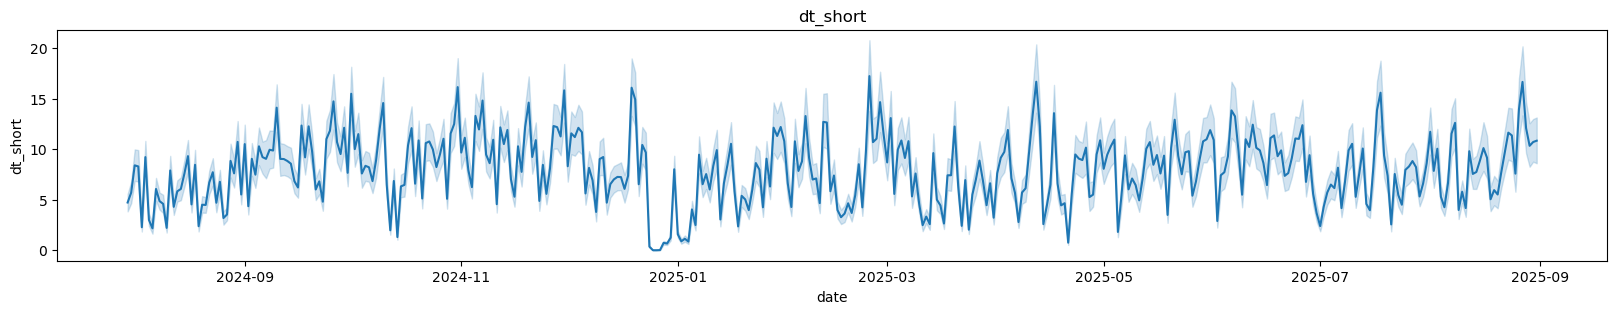

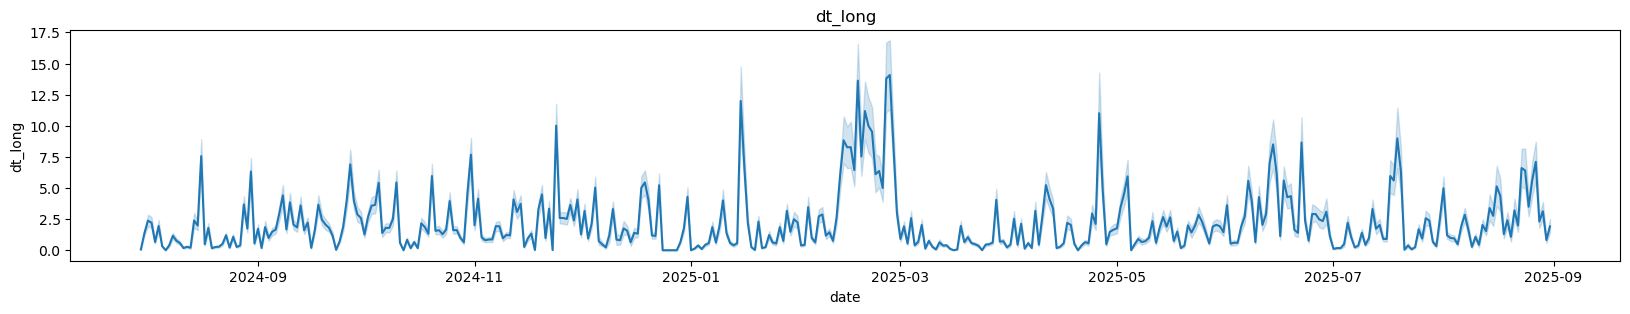

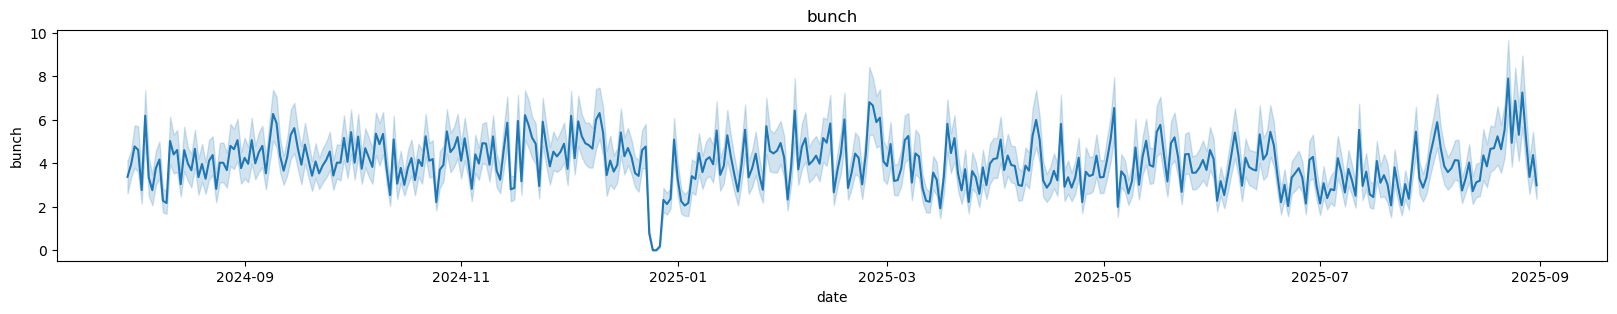

In [15]:
for dt in ['dt_short', 'dt_long']:
    plt.figure(figsize=(20,3))
    sns.lineplot(data=daily_df, x='date', y=dt)
    plt.title(dt)
    plt.show()

plt.figure(figsize=(20,3))
sns.lineplot(data=daily_df, x='date', y='bunch')
plt.title('bunch')
plt.show()

Some of the feature of the long term weight can be explained by snowfall.

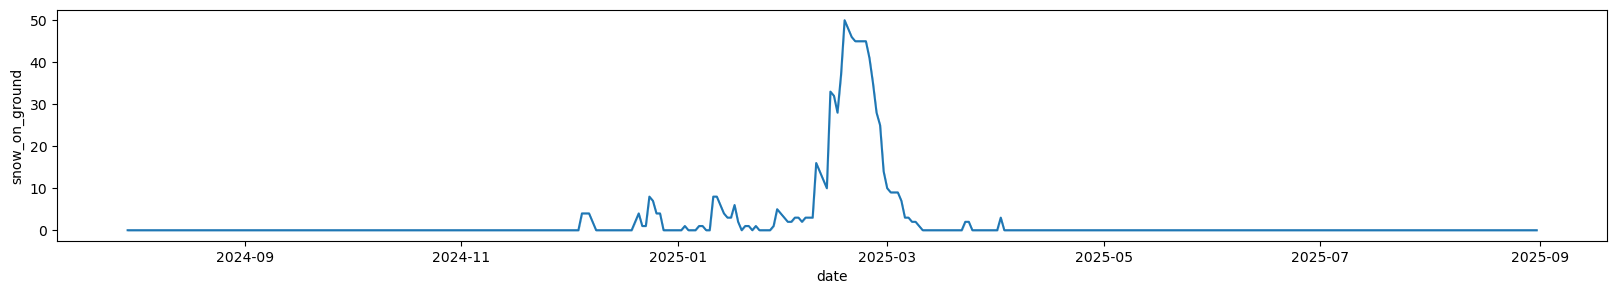

In [16]:
plt.figure(figsize=(20,3))
sns.lineplot(data=daily_df, x='date', y='snow_on_ground')
plt.show()

Another region of 'spikes' corresponds to some of the hottest days of the year.

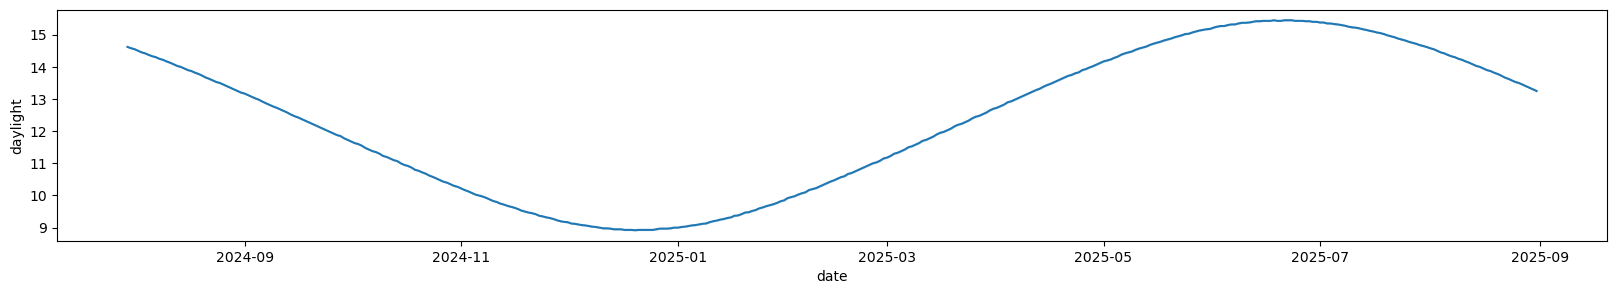

In [17]:
plt.figure(figsize=(20,3))
sns.lineplot(data=daily_df, x='date', y='daylight')
plt.show()

The ACF and PACF plots show no strong correlation between bunch events per day.

In [18]:
def count_feature(date, feature, df):
    if len(df[df['date'] == date][feature].tolist())==0:
        return 0
    else:
        return sum(df[df['date'] == date][feature])

bunch_events = []
start_date = daily_df.date.min()
end_date = daily_df.date.max()
timedelta = (end_date - start_date).days
for delta in range(timedelta):
    bunch_events.append(count_feature(start_date+pd.Timedelta(days=delta), 'bunch', daily_df))

bunch_events = np.array(bunch_events)

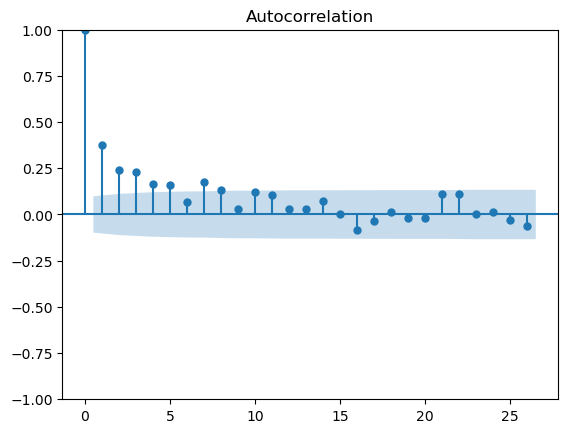

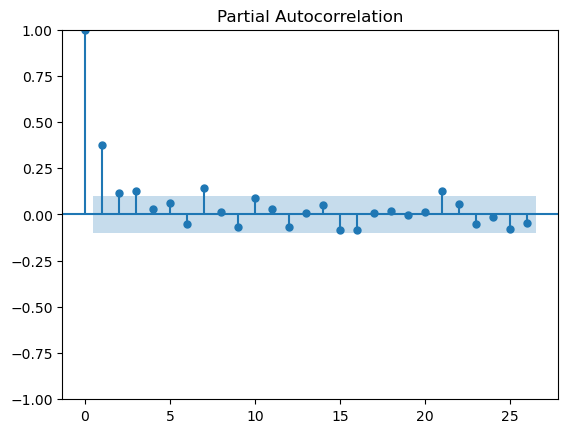

In [19]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
plot_acf(bunch_events)
plt.show()
plot_pacf(bunch_events)
plt.show()

We use xgboost since it's a very flexible model that generalizes well. According to (https://stats.stackexchange.com/questions/338904/measures-of-ordinal-classification-error-for-ordinal-regression)[this post on Cross Validated], RMSE is the best measure of performance for ordinal classification when the classes are reasonably balanced, and MAE should not be used. Note that 'dt_long' is *not* balanced, and so we will have to come to an analysis of this with a different metric.

In [20]:
# Let's try xgboost since it is a very flexible model
import xgboost as xgb
# First turn stop into a categorical feature.
daily_df['stop']=daily_df['stop'].astype('category')
daily_df['dir']=daily_df['dir'].astype('category')

loss = dict()
R2_score = dict()
features = ['bunch', 'gap', 'avg_temperature', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain',
            'snow_on_ground',
            'daylight', 'dir', 'stop']

tss = TimeSeriesSplit(n_splits=5, test_size=30)
for target in ['dt_short', 'dt_long']:
    for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
        df_train = daily_df.iloc[tss_train]
        df_test = daily_df.iloc[tss_test]

        model = xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=200,
                                enable_categorical=True,
                                learning_rate=0.1,
                                max_depth=10,
                                reg_alpha=2,
                                reg_lambda=0,
                                seed=37)

        X_train = df_train[features]
        y_train = df_train[target]
        X_test = df_test[features]
        y_test = df_test[target]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        R2_score[target,idx] = r2_score(y_test, y_pred)
        loss[target,idx] = rmse(y_test, y_pred)

for dt in ['dt_short', 'dt_long']:
    print(f'{dt} rmse mean: {np.array([val for key,val in loss.items() if key[0] == dt]).mean()}')
    print(f'{dt} rmse std: {np.array([val for key,val in loss.items() if key[0] == dt]).std()}')
    print(f'{dt} average R^2 score: {np.array([val for key,val in R2_score.items() if key[0] == dt]).mean()}')
    print(f'{dt} R^2 score std: {np.array([val for key,val in R2_score.items() if key[0] == dt]).std()}\n')

dt_short rmse mean: 5.0351489067077635
dt_short rmse std: 1.0722760578034678
dt_short average R^2 score: 0.8642028212547302
dt_short R^2 score std: 0.04633110639890117

dt_long rmse mean: 1.9309625387191773
dt_long rmse std: 0.7181884342330139
dt_long average R^2 score: 0.5428024411201477
dt_long R^2 score std: 0.2307435651535877



We're going to try to use Shapley values to do some analysis on the feature set, mimicking [Wendy's analysis on the effect of gender on pay](https://www.kaggle.com/code/manwaicheung/gender-pay-gap). One factor that we want to isolate is the direction of the streetcar.

In [21]:
import shap
shap.initjs()

In [22]:
df_filter = dict()
y_filter = dict()
X_filter= dict()
for target in ['dt_short', 'dt_long']:
    for dir in daily_df.dir.unique():
        df_filter[str(dir), target] = daily_df[(daily_df['dir']==dir)]
        X_filter[str(dir), target] = df_filter[str(dir), target][[x for x in features]]
        y_filter[str(dir), target] = df_filter[str(dir), target][target]


In [23]:
model_filter = dict()
for key in df_filter.keys():
    model_filter[key] = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=200,
    learning_rate=0.1,
    enable_categorical=True,
    max_depth=10,
    reg_alpha=2,
    reg_lambda=0,
    seed=37)
    model_filter[key].fit(X_filter[key], y_filter[key])

In [24]:
explainer_filter = dict()
shap_filter = dict()
for key in df_filter.keys():
    explainer_filter[key] = shap.Explainer(model_filter[key])
    shap_filter[key] = explainer_filter[key](X_filter[key])

Lets first see a waterfall plot to see how our function compares to the baseline

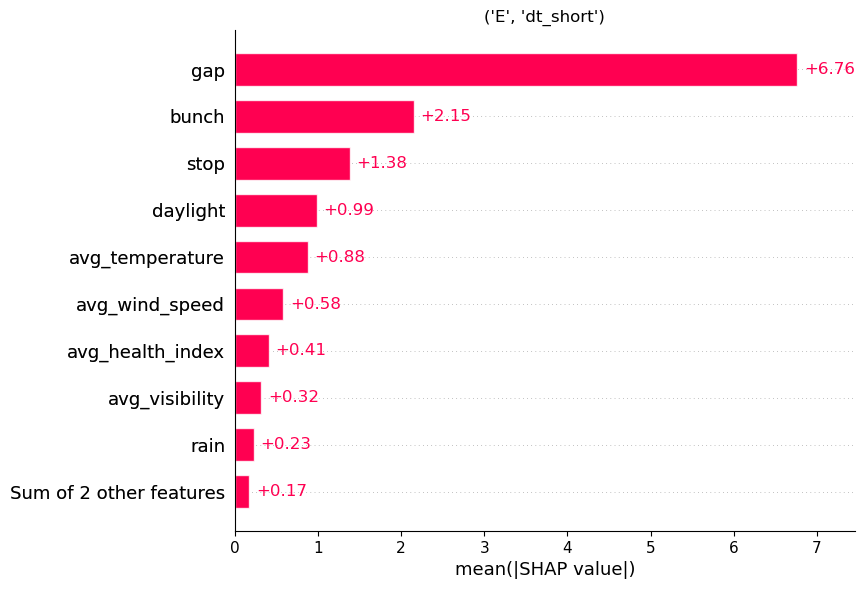

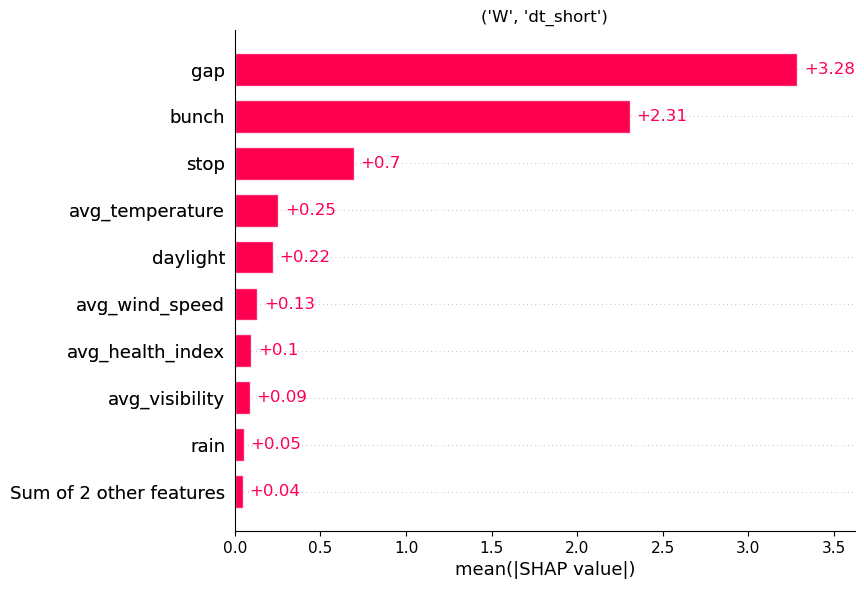

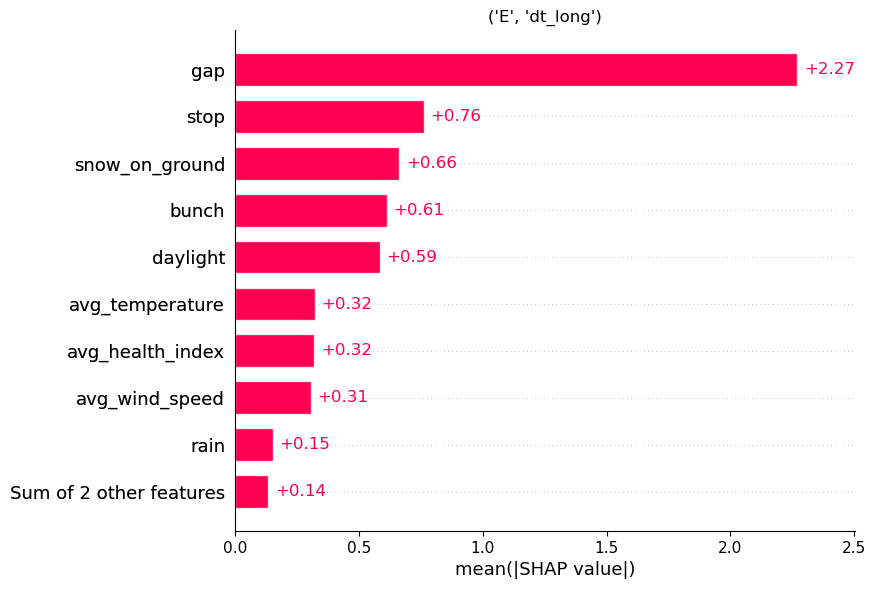

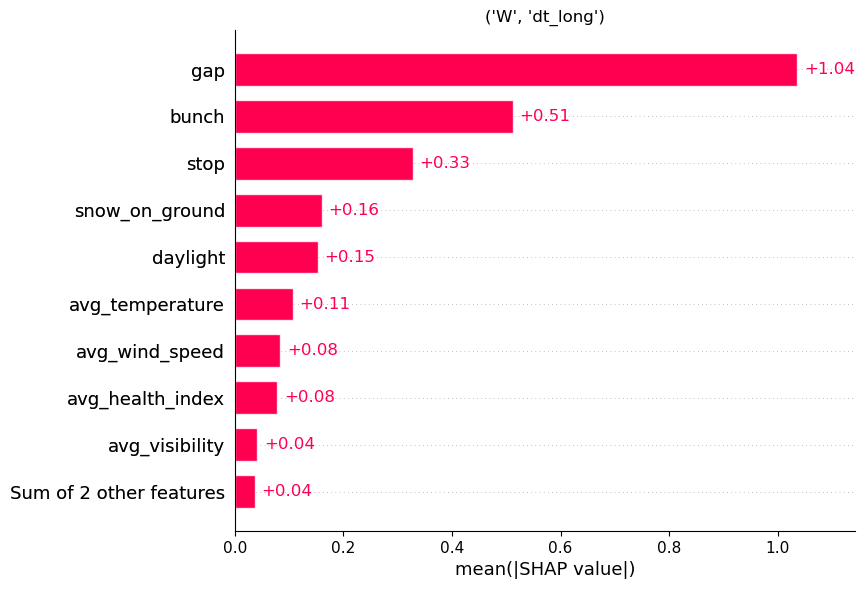

In [25]:
for key in df_filter.keys():
    shap.plots.bar(shap_filter[key], show=False)
    plt.title(str(key))
    plt.show()

That gap seems to be so dominant is very suspicious, especially since gapping events are defined as gaps between streetcars that are at least 19 minutes long. Therefore, we rerun the model without it.

In [26]:
loss = dict()
R2_score = dict()
features = ['bunch', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight', 'dir', 'stop']

tss = TimeSeriesSplit(n_splits=5, test_size=30)
for target in ['dt_short', 'dt_long']:
    for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
        df_train = daily_df.iloc[tss_train]
        df_test = daily_df.iloc[tss_test]

        model = xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=200,
                                enable_categorical=True,
                                learning_rate=0.1,
                                max_depth=10,
                                reg_lambda=2,
                                reg_alpha=0,
                                seed=37)

        X_train = df_train[features]
        y_train = df_train[target]
        X_test = df_test[features]
        y_test = df_test[target]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        R2_score[target,idx] = r2_score(y_test, y_pred)
        loss[target,idx] = rmse(y_test, y_pred)
for dt in ['dt_short', 'dt_long']:
    print(f'{dt} rmse mean: {np.array([val for key,val in loss.items() if key[0] == dt]).mean()}')
    print(f'{dt} rmse std: {np.array([val for key,val in loss.items() if key[0] == dt]).std()}')
    print(f'{dt} average R^2 score: {np.array([val for key,val in R2_score.items() if key[0] == dt]).mean()}')
    print(f'{dt} R^2 score std: {np.array([val for key,val in R2_score.items() if key[0] == dt]).std()}\n')

print(R2_score)

dt_short rmse mean: 4.7043663501739506
dt_short rmse std: 1.5096491050216496
dt_short average R^2 score: 0.8784827828407288
dt_short R^2 score std: 0.06052519631309668

dt_long rmse mean: 1.7171316862106323
dt_long rmse std: 0.3011214220623755
dt_long average R^2 score: 0.5935935258865357
dt_long R^2 score std: 0.21865584936627647

{('dt_short', 0): 0.7908333539962769, ('dt_short', 1): 0.8547924160957336, ('dt_short', 2): 0.9398132562637329, ('dt_short', 3): 0.8531836271286011, ('dt_short', 4): 0.9537912607192993, ('dt_long', 0): 0.595893144607544, ('dt_long', 1): 0.49767231941223145, ('dt_long', 2): 0.23883283138275146, ('dt_long', 3): 0.8594214916229248, ('dt_long', 4): 0.7761478424072266}


Let us do some hyperparameter tuning on this model.

In [ ]:
loss = dict()
R2_score = dict()
features = ['bunch', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight', 'dir', 'stop']

tss = TimeSeriesSplit(n_splits=5, test_size=30)
target = 'dt_short'
lambda_vals = [0,1,3,5,10,20]
alpha_vals = [0,1,3,5,10,20]
depth_vals = [5,10,15,20]
est_vals = [100,200]

params = dict()
for l in lambda_vals:
    for a in alpha_vals:
        for d in depth_vals:
            for n in est_vals:
                params[l,a,d,n] = (l,a,d,n)

for param in params.keys():
    for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
        df_train = daily_df.iloc[tss_train]
        df_test = daily_df.iloc[tss_test]

        model = xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=param[3],
                                enable_categorical=True,
                                learning_rate=0.1,
                                max_depth=param[2],
                                reg_lambda=param[0],
                                reg_alpha=param[1],
                                seed=37)

        X_train = df_train[features]
        y_train = df_train[target]
        X_test = df_test[features]
        y_test = df_test[target]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        R2_score[param,idx] = r2_score(y_test, y_pred)
        loss[param,idx] = rmse(y_test, y_pred)

In [ ]:
for param in params.keys():
    print(f'param: {param}')
    print(f'{target} rmse mean: {np.array([val for key,val in loss.items() if key[0] == param]).mean()}')
    print(f'{target} rmse std: {np.array([val for key,val in loss.items() if key[0] == param]).std()}')

In [ ]:
best_loss = np.inf
best_R2 = 0
best_loss_param = (0,0,0,0)
best_R2_param = (0,0,0,0)
for param in params.keys():
    curr_loss = np.array([loss[param, idx] for idx in range(5)]).mean()
    curr_R2 = np.array([R2_score[param, idx] for idx in range(5)]).mean()
    if curr_loss < best_loss:
        best_loss = loss[param, idx]
        best_loss_param = param
    if curr_R2 > best_R2:
        best_R2 = curr_R2
        best_R2_param = param

print(best_loss, best_loss_param, best_R2, best_R2_param)
print([loss[best_loss_param, idx] for idx in range(5)])
print([R2_score[best_loss_param, idx] for idx in range(5)])

print([loss[best_R2_param, idx] for idx in range(5)])
print([R2_score[best_R2_param, idx] for idx in range(5)])

In [ ]:
loss = dict()
R2_score = dict()
features = ['bunch', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight', 'dir', 'stop']

tss = TimeSeriesSplit(n_splits=5, test_size=30)
target = 'dt_long'
lambda_vals = [0,1,3,5,10,20]
alpha_vals = [0,1,3,5,10,20]
depth_vals = [5,10,15,20]
est_vals = [100,200]

params = dict()
for l in lambda_vals:
    for a in alpha_vals:
        for d in depth_vals:
            for n in est_vals:
                params[l,a,d,n] = (l,a,d,n)

for param in params.keys():
    for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
        df_train = daily_df.iloc[tss_train]
        df_test = daily_df.iloc[tss_test]

        model = xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=param[3],
                                enable_categorical=True,
                                learning_rate=0.1,
                                max_depth=param[2],
                                reg_lambda=param[0],
                                reg_alpha=param[1],
                                seed=37)

        X_train = df_train[features]
        y_train = df_train[target]
        X_test = df_test[features]
        y_test = df_test[target]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        R2_score[param,idx] = r2_score(y_test, y_pred)
        loss[param,idx] = rmse(y_test, y_pred)

In [ ]:
for param in params.keys():
    print(f'param: {param}')
    print(f'{target} rmse mean: {np.array([val for key,val in loss.items() if key[0] == param]).mean()}')
    print(f'{target} rmse std: {np.array([val for key,val in loss.items() if key[0] == param]).std()}')
    print(f'{target} average R^2 score: {np.array([val for key,val in R2_score.items() if key[0] == param]).mean()}')
    print(f'{target} R^2 score std: {np.array([val for key,val in R2_score.items() if key[0] == param]).std()}\n')

In [ ]:
best_loss = np.inf
best_R2 = 0
best_loss_param = (0,0,0,0)
best_R2_param = (0,0,0,0)
for param in params.keys():
    curr_loss = np.array([loss[param, idx] for idx in range(5)]).mean()
    curr_R2 = np.array([R2_score[param, idx] for idx in range(5)]).mean()
    if curr_loss < best_loss:
        best_loss = loss[param, idx]
        best_loss_param = param
    if curr_R2 > best_R2:
        best_R2 = curr_R2
        best_R2_param = param

print(best_loss, best_loss_param, best_R2, best_R2_param)
print([loss[best_loss_param, idx] for idx in range(5)])
print([R2_score[best_loss_param, idx] for idx in range(5)])

print([loss[best_R2_param, idx] for idx in range(5)])
print([R2_score[best_R2_param, idx] for idx in range(5)])

Actually, the second model does pretty well in general, so I think I will use these parameters for my final analysis.

In [ ]:
df_filter = dict()
y_filter = dict()
X_filter= dict()
features = ['bunch', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight', 'dir', 'stop']
for target in ['dt_short', 'dt_long']:
    df_filter[target] = daily_df
    X_filter[target] = df_filter[target][[x for x in features]]
    y_filter[target] = df_filter[target][target]

model_filter = dict()
for key in df_filter.keys():
    model_filter[key] = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100,
    learning_rate=0.1,
    enable_categorical=True,
    max_depth=5,
    reg_lambda=4,
    reg_alpha=0,
    seed=37)
    model_filter[key].fit(X_filter[key], y_filter[key])

explainer_filter = dict()
shap_filter = dict()
for key in df_filter.keys():
    explainer_filter[key] = shap.Explainer(model_filter[key])
    shap_filter[key] = explainer_filter[key](X_filter[key])

for key in df_filter.keys():
    shap.plots.bar(shap_filter[key], show=False)
    plt.title(str(key))
    plt.show()

Finally, we can look at the distribution of the features.

In [ ]:
for key in df_filter.keys():
    shap.plots.beeswarm(shap_filter[key], show=False)
    plt.title(str(key))
    plt.show()

In fact, the short term delay time is also a strong predictor for the amount of gap events, suggesting that gap does not make a good feature for prediction.

In [ ]:
loss = dict()
R2_score = dict()
features = ['dt_short', 'dir', 'stop']

tss = TimeSeriesSplit(n_splits=5, test_size=30)
for target in ['bunch','gap']:
    for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
        df_train = daily_df.iloc[tss_train]
        df_test = daily_df.iloc[tss_test]

        model = xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=100,
                                enable_categorical=True,
                                learning_rate=0.1,
                                max_depth=10,
                                reg_lambda=5,
                                reg_alpha=0,
                                seed=37)

        X_train = df_train[features]
        y_train = df_train[target]
        X_test = df_test[features]
        y_test = df_test[target]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        R2_score[target,idx] = r2_score(y_test, y_pred)
        loss[target,idx] = rmse(y_test, y_pred)

for dt in ['bunch','gap']:
    print(f'{dt} rmse mean: {np.array([val for key,val in loss.items() if key[0] == dt]).mean()}')
    print(f'{dt} rmse std: {np.array([val for key,val in loss.items() if key[0] == dt]).std()}')
    print(f'{dt} average R^2 score: {np.array([val for key,val in R2_score.items() if key[0] == dt]).mean()}')
    print(f'{dt} R^2 score std: {np.array([val for key,val in R2_score.items() if key[0] == dt]).std()}\n')


Some hyperparameter tuning to try to see if 'bunch' can be predicted from the above information.

In [ ]:
loss = dict()
R2_score = dict()
features = ['dt_short', 'dir', 'stop']

tss = TimeSeriesSplit(n_splits=5, test_size=30)
target = 'bunch'
lambda_vals = [0,1,3,5,10,20]
alpha_vals = [0,1,3,5,10,20]
depth_vals = [5,10,15,20]
est_vals = [100,200]

params = dict()
for l in lambda_vals:
    for a in alpha_vals:
        for d in depth_vals:
            for n in est_vals:
                params[l,a,d,n] = (l,a,d,n)

for param in params.keys():
    for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
        df_train = daily_df.iloc[tss_train]
        df_test = daily_df.iloc[tss_test]

        model = xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=param[3],
                                enable_categorical=True,
                                learning_rate=0.1,
                                max_depth=param[2],
                                reg_lambda=param[0],
                                reg_alpha=param[1],
                                seed=37)

        X_train = df_train[features]
        y_train = df_train[target]
        X_test = df_test[features]
        y_test = df_test[target]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        R2_score[param,idx] = r2_score(y_test, y_pred)
        loss[param,idx] = rmse(y_test, y_pred)

In [ ]:
for param in params.keys():
    print(f'param: {param}')
    print(f'{target} rmse mean: {np.array([val for key,val in loss.items() if key[0] == param]).mean()}')
    print(f'{target} rmse std: {np.array([val for key,val in loss.items() if key[0] == param]).std()}')
    print(f'{target} average R^2 score: {np.array([val for key,val in R2_score.items() if key[0] == param]).mean()}')
    print(f'{target} R^2 score std: {np.array([val for key,val in R2_score.items() if key[0] == param]).std()}\n')

best_loss = np.inf
best_R2 = 0
best_loss_param = (0,0,0,0)
best_R2_param = (0,0,0,0)
for param in params.keys():
    curr_loss = np.array([loss[param, idx] for idx in range(5)]).mean()
    curr_R2 = np.array([R2_score[param, idx] for idx in range(5)]).mean()
    if curr_loss < best_loss:
        best_loss = loss[param, idx]
        best_loss_param = param
    if curr_R2 > best_R2:
        best_R2 = curr_R2
        best_R2_param = param

In [ ]:
print(best_loss, best_loss_param, best_R2, best_R2_param)
print([loss[best_loss_param, idx] for idx in range(5)])
print([R2_score[best_loss_param, idx] for idx in range(5)])

print([loss[best_R2_param, idx] for idx in range(5)])
print([R2_score[best_R2_param, idx] for idx in range(5)])

This is pretty bad, which adds to evidence that bunch events alone cannot predict delays. Finally, we try the other way around.

In [ ]:
loss = dict()
R2_score = dict()
features = ['bunch', 'dir', 'stop']

tss = TimeSeriesSplit(n_splits=5, test_size=30)
target = 'dt_short'
lambda_vals = [0,1,3,5,10,20]
alpha_vals = [0,1,3,5,10,20]
depth_vals = [5,10,15,20]
est_vals = [100,200]

params = dict()
for l in lambda_vals:
    for a in alpha_vals:
        for d in depth_vals:
            for n in est_vals:
                params[l,a,d,n] = (l,a,d,n)

for param in params.keys():
    for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
        df_train = daily_df.iloc[tss_train]
        df_test = daily_df.iloc[tss_test]

        model = xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=param[3],
                                enable_categorical=True,
                                learning_rate=0.1,
                                max_depth=param[2],
                                reg_lambda=param[0],
                                reg_alpha=param[1],
                                seed=37)

        X_train = df_train[features]
        y_train = df_train[target]
        X_test = df_test[features]
        y_test = df_test[target]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        R2_score[param,idx] = r2_score(y_test, y_pred)
        loss[param,idx] = rmse(y_test, y_pred)

In [ ]:
for param in params.keys():
    print(f'param: {param}')
    print(f'{target} rmse mean: {np.array([val for key,val in loss.items() if key[0] == param]).mean()}')
    print(f'{target} rmse std: {np.array([val for key,val in loss.items() if key[0] == param]).std()}')
    print(f'{target} average R^2 score: {np.array([val for key,val in R2_score.items() if key[0] == param]).mean()}')
    print(f'{target} R^2 score std: {np.array([val for key,val in R2_score.items() if key[0] == param]).std()}\n')

best_loss = np.inf
best_R2 = 0
best_loss_param = (0,0,0,0)
best_R2_param = (0,0,0,0)
for param in params.keys():
    curr_loss = np.array([loss[param, idx] for idx in range(5)]).mean()
    curr_R2 = np.array([R2_score[param, idx] for idx in range(5)]).mean()
    if curr_loss < best_loss:
        best_loss = loss[param, idx]
        best_loss_param = param
    if curr_R2 > best_R2:
        best_R2 = curr_R2
        best_R2_param = param

In [ ]:
print(best_loss, best_loss_param, best_R2, best_R2_param)
print([loss[best_loss_param, idx] for idx in range(5)])
print([R2_score[best_loss_param, idx] for idx in range(5)])

print([loss[best_R2_param, idx] for idx in range(5)])
print([R2_score[best_R2_param, idx] for idx in range(5)])

A much better predictor, which is a good sign.

In [ ]:
features = ['bunch', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight', 'dir', 'stop']
tss = TimeSeriesSplit(n_splits=2, test_size=120)
tss_split = tss.split(daily_df, daily_df.date)
next(tss_split)
tss_train, tss_test = next(tss_split)

df_train = daily_df.iloc[tss_train]
df_test = daily_df.iloc[tss_test]

dt = 'dt_long'

model = xgb.XGBRegressor(objective='reg:squarederror',
                        n_estimators=200,
                        enable_categorical=True,
                        learning_rate=0.1,
                        max_depth=10,
                        reg_alpha=2,
                        reg_lambda=0,
                        seed=37)

X_train = df_train[features]
y_train = df_train[dt]


X_test = df_test[features]
y_test = df_test[dt]


model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)

df_pred = df_test.copy()
df_pred[dt] = y_pred


df_pred_train = df_train.copy()
df_pred_train[dt] = y_pred_train

In [ ]:
plt.figure(figsize=(20,5))
sns.lineplot(x=range(120), y=y_test)
sns.lineplot(x=range(120), y=y_pred)